Bibliotheken & Daten laden

In [1]:
import pandas as pd 
matches = pd.read_csv("../data/processed/btts_features_v2.csv")

Die neuen Features auswählen (10 Features statt 6)

In [2]:
feature_columns = [
    "HomeGoalsLast5",
    "AwayGoalsLast5",
    "HomeConcededLast5",
    "AwayConcededLast5",
    "HomeFormLast5",
    "AwayFormLast5",
    "HomeShotsOnTargetLast5",
    "AwayShotsOnTargetLast5",
    "HomeBTTSLast5",
    "AwayBTTSLast5"
]

target = "BTTS"

Fehlende Werte entfernen

In [3]:
matches = matches.dropna(subset=feature_columns)

Features und Zielvariable erstellen

In [4]:
X = matches[feature_columns]

y = matches[target]

Train/Test-Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Features skalieren

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Modell erstellen

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
model_v2 = Sequential([
    Input(shape=(10,)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_v2.compile(
    optimizer="adam", 
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


model_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Early Stopping (Wenn sich der Fehler 5 Epochen lang nicht verbessert, stoppt das Training automatisch und lädt den besten Modellstand wieder.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Modell trainieren

In [9]:
history_v2 = model_v2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4906 - loss: 0.7178 - val_accuracy: 0.5188 - val_loss: 0.6928
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5452 - loss: 0.6936 - val_accuracy: 0.5256 - val_loss: 0.6931
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5520 - loss: 0.6915 - val_accuracy: 0.5188 - val_loss: 0.6944
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5708 - loss: 0.6834 - val_accuracy: 0.5324 - val_loss: 0.6937
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5742 - loss: 0.6850 - val_accuracy: 0.5188 - val_loss: 0.6944
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5691 - loss: 0.6787 - val_accuracy: 0.5324 - val_loss: 0.6957


eigentliche Bewertung

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred_prob = model_v2.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy : 0.4986376021798365
Precision: 0.5209003215434084
Recall   : 0.8223350253807107
F1 Score : 0.6377952755905512


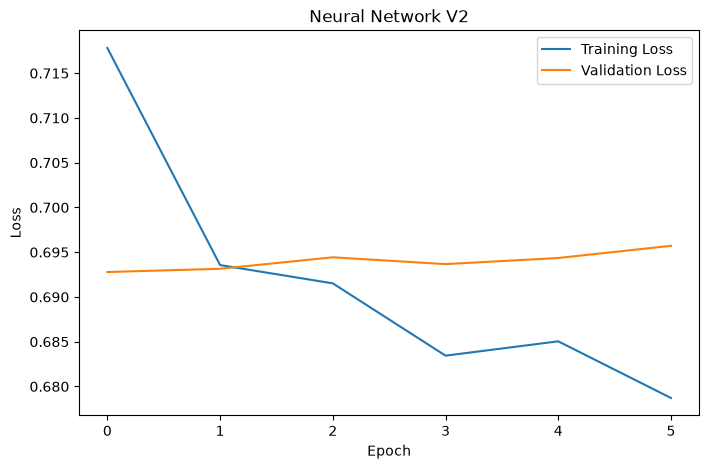

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")

plt.title("Neural Network V2")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

Bewertung Modell V2

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_prob_v2 = model_v2.predict(X_test)

y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_v2))
print("Precision:", precision_score(y_test, y_pred_v2))
print("Recall   :", recall_score(y_test, y_pred_v2))
print("F1 Score :", f1_score(y_test, y_pred_v2))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy : 0.4986376021798365
Precision: 0.5209003215434084
Recall   : 0.8223350253807107
F1 Score : 0.6377952755905512


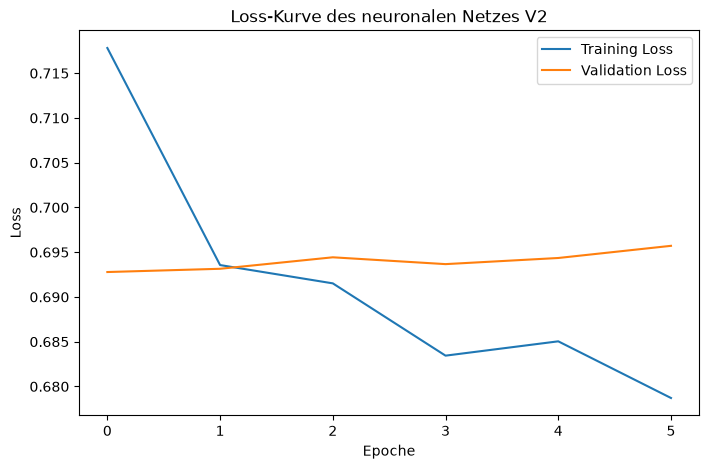

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")

plt.title("Loss-Kurve des neuronalen Netzes V2")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()

plt.show()

Model speichern

In [14]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_v2.save("../models/neural_network_v2.keras")
joblib.dump(scaler, "../models/scaler_v2.pkl")

print("Alles gespeichert!")

Alles gespeichert!
